# Tier 4 · Notebook 21 — RLHF: Reward Model + PPO + DPO

> **Goal:** understand how a raw language model is **aligned to human preferences** — the pipeline behind ChatGPT/Claude. We build the three pieces from scratch on a controlled toy: a **reward model** (Bradley-Terry) from preference comparisons, **PPO** (the original RLHF optimizer), and **DPO** (the simpler method that now dominates) — and see them all move a policy toward preferred behavior.

**The alignment problem.** A pretrained LM (NB11) predicts *plausible text*, not *helpful, honest, harmless* responses — those aren't the same thing. But "helpfulness" has no loss function; you can't write it down. The RLHF insight: **humans can't specify good behavior, but they can *compare* two responses and say which is better.** So we (1) collect preference comparisons, (2) train a **reward model** to predict them, and (3) optimize the LM to maximize that reward *without drifting too far from its pretrained self* (a KL penalty keeps it coherent). That's RLHF. **DPO** later showed you can skip the reward model and RL entirely and get the same objective with a simple classification loss.

Real RLHF runs on billion-parameter LMs and human labels — we can't do that here. Instead we use a **controlled toy** where the "true" human preference is known, so we can *verify* each component actually recovers it.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- toy "language": length-T sequences over a small vocab ---
V, T = 6, 5
# GROUND-TRUTH human preference: "responses with more of token 0 are better" (stand-in for helpfulness)
def true_reward(seq):            # seq: (..., T) int tensor
    return (seq == 0).float().sum(-1)      # count of token-0

# a factorized policy: independent categorical per position (keeps the RL math clean & fast)
def sample(logits, n):           # logits: (T, V) -> n sampled sequences (n, T)
    p = F.softmax(logits, -1)
    return torch.stack([torch.multinomial(p[t], n, replacement=True) for t in range(T)], dim=1)
def logprob(logits, seq):        # log pi(seq) = sum_t log softmax(logits[t])[seq_t]
    lp = F.log_softmax(logits, -1)
    return lp[torch.arange(T), seq].sum(-1)      # seq: (T,) -> scalar; batched below

print(f"toy: vocab {V}, length {T}. True preference: more token-0 = better (max reward {T}).")
print("reference (pretrained) policy = uniform over tokens.")


toy: vocab 6, length 5. True preference: more token-0 = better (max reward 5).
reference (pretrained) policy = uniform over tokens.


## 1. Preference data + the reward model (Bradley-Terry)

Humans give **comparisons**: shown two responses $y_w$ (preferred/"win") and $y_l$ (rejected/"lose"), they pick $y_w$. The **Bradley-Terry** model says the probability a human prefers $y_w$ is a logistic function of the reward difference:
$$P(y_w \succ y_l) = \sigma\big(r(y_w) - r(y_l)\big).$$
So we train a reward model $r_\theta$ by **maximizing the likelihood** of the observed preferences — equivalently, minimizing $-\log\sigma(r_\theta(y_w) - r_\theta(y_l))$. It's just logistic regression on reward *differences*. Let's generate preference pairs (labeled by our known true reward) and fit the reward model.


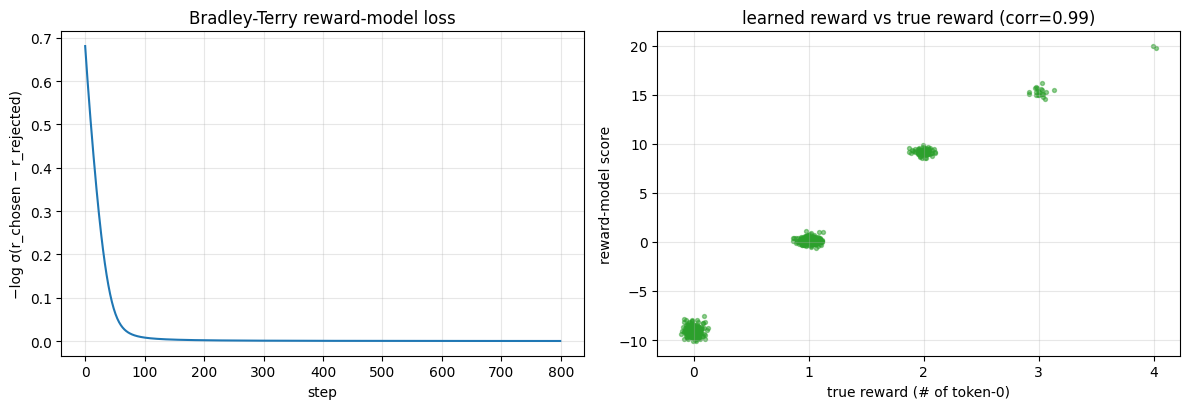

reward model recovered the true preference: correlation 0.995


In [2]:
# generate preference pairs: sample 2 sequences, label the higher-true-reward one as "chosen"
def make_prefs(n):
    a = torch.randint(0, V, (n, T)); b = torch.randint(0, V, (n, T))
    ra, rb = true_reward(a), true_reward(b)
    chosen = torch.where((ra >= rb)[:, None], a, b)
    rejected = torch.where((ra >= rb)[:, None], b, a)
    keep = ra != rb                      # drop ties
    return chosen[keep], rejected[keep]
chosen, rejected = make_prefs(4000)
chosen, rejected = chosen.to(device), rejected.to(device)

class RewardModel(nn.Module):           # scores a sequence -> scalar reward
    def __init__(s): super().__init__(); s.emb=nn.Embedding(V,16); s.net=nn.Sequential(nn.Linear(16*T,64),nn.GELU(),nn.Linear(64,1))
    def forward(s,x): return s.net(s.emb(x).flatten(1)).squeeze(-1)

rm = RewardModel().to(device); opt = torch.optim.Adam(rm.parameters(), 1e-3)
bt_losses = []
for step in range(800):
    rc, rl = rm(chosen), rm(rejected)
    loss = -F.logsigmoid(rc - rl).mean()          # Bradley-Terry loss
    opt.zero_grad(); loss.backward(); opt.step(); bt_losses.append(loss.item())

# verify: does the learned reward correlate with the TRUE reward?
with torch.no_grad():
    test = torch.randint(0, V, (500, T), device=device)
    pred_r = rm(test).cpu().numpy(); true_r = true_reward(test.cpu()).numpy()
corr = np.corrcoef(pred_r, true_r)[0,1]
fig, ax = plt.subplots(1,2,figsize=(12,4.2))
ax[0].plot(bt_losses, color="tab:blue"); ax[0].set_title("Bradley-Terry reward-model loss")
ax[0].set_xlabel("step"); ax[0].set_ylabel("−log σ(r_chosen − r_rejected)"); ax[0].grid(alpha=0.3)
ax[1].scatter(true_r + np.random.randn(500)*0.05, pred_r, s=8, alpha=0.5, color="tab:green")
ax[1].set_title(f"learned reward vs true reward (corr={corr:.2f})")
ax[1].set_xlabel("true reward (# of token-0)"); ax[1].set_ylabel("reward-model score"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"reward model recovered the true preference: correlation {corr:.3f}")
assert corr > 0.9, \
    f"Bradley-Terry reward model only reached correlation {corr:.3f} with the true reward"


**What to notice.** The reward model, trained *only* on binary comparisons (never seeing the true reward), learns a score that is **strongly correlated** with the true reward — it inferred the underlying preference from pairwise choices. This is exactly what RLHF's reward model does with human comparison labels: distill fuzzy human judgments into a differentiable scalar we can optimize. The Bradley-Terry loss is the workhorse. Now we optimize a policy against this learned reward — two ways.


## 2. PPO — the original RLHF optimizer

RLHF's optimization objective: maximize the reward model's score while staying close to the reference (pretrained) policy, measured by KL divergence:
$$\max_\pi \; \mathbb{E}_{y\sim\pi}[\,r(y)\,] - \beta\,\mathrm{KL}\big(\pi \,\|\, \pi_\text{ref}\big).$$
The reward term pushes toward high-reward outputs; the **KL penalty** prevents the policy from collapsing onto a few reward-hacking outputs or forgetting how to produce coherent text. **PPO** (Proximal Policy Optimization) maximizes this with a *clipped* policy-gradient update that limits how far the policy moves per step (for stability). We implement a minimal-but-faithful PPO on our toy: sample, score with the reward model, and take clipped policy-gradient steps with a KL-to-reference penalty.


In [3]:
ref_logits = torch.zeros(T, V, device=device)                 # uniform reference (pretrained) policy
policy = torch.zeros(T, V, device=device, requires_grad=True)  # start = reference
opt = torch.optim.Adam([policy], lr=0.05)
beta = 0.1                                                     # KL penalty weight
ppo_reward, ppo_kl = [], []

def batch_logprob(logits, seqs):     # logits (T,V), seqs (n,T) -> (n,)
    lp = F.log_softmax(logits, -1)
    return lp[torch.arange(T)[None,:], seqs].sum(-1)

for it in range(150):
    with torch.no_grad():
        seqs = sample(policy, 256).to(device)                 # sample responses
        rew = rm(seqs)                                          # reward-model score
        old_lp = batch_logprob(policy, seqs)
        adv = (rew - rew.mean()) / (rew.std() + 1e-8)          # advantage (baseline-subtracted)
    for _ in range(4):                                         # a few PPO epochs per batch
        new_lp = batch_logprob(policy, seqs)
        ratio = torch.exp(new_lp - old_lp)                     # importance ratio
        clip = torch.clamp(ratio, 0.8, 1.2)                    # PPO clipping
        pg = -torch.min(ratio*adv, clip*adv).mean()            # clipped surrogate objective
        kl = (batch_logprob(policy, seqs) - batch_logprob(ref_logits, seqs)).mean()  # KL to reference
        loss = pg + beta*kl
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        s = sample(policy, 512).to(device)
        ppo_reward.append(true_reward(s.cpu()).mean().item())
        ppo_kl.append((batch_logprob(policy, s) - batch_logprob(ref_logits, s)).mean().item())
print(f"PPO: true reward went from ~{T/V:.2f} (uniform) to {ppo_reward[-1]:.2f} (max {T}); final KL {ppo_kl[-1]:.2f}")


PPO: true reward went from ~0.83 (uniform) to 5.00 (max 5); final KL 8.96


## 3. DPO — skip the reward model and the RL

DPO (Direct Preference Optimization, 2023) made a beautiful observation: the RLHF objective in §2 has a **closed-form optimal policy**, and you can algebraically rearrange it so the reward model *cancels out*. The result is a simple supervised loss directly on the preference pairs — no reward model, no sampling, no RL:
$$\mathcal{L}_\text{DPO} = -\log\sigma\!\left(\beta\Big[\big(\log\pi(y_w) - \log\pi_\text{ref}(y_w)\big) - \big(\log\pi(y_l) - \log\pi_\text{ref}(y_l)\big)\Big]\right).$$
In words: **increase the policy's log-prob of preferred responses and decrease it for rejected ones**, measured *relative to the reference* (the $\log\pi - \log\pi_\text{ref}$ terms), scaled by $\beta$. It's the Bradley-Terry loss again, but with the policy's own implicit reward $\beta\log\frac{\pi}{\pi_\text{ref}}$ substituted in. Simpler, more stable, no reward model — which is why it largely replaced PPO for preference tuning. Let's implement it on the *same* preference data.


In [4]:
policy_dpo = torch.zeros(T, V, device=device, requires_grad=True)   # start = reference
opt = torch.optim.Adam([policy_dpo], lr=0.05)
beta = 0.1
dpo_reward, dpo_kl, dpo_loss_hist = [], [], []
ch, rj = chosen, rejected      # reuse the preference pairs from section 1

for it in range(300):
    # implicit rewards: beta * (logpi - logpi_ref) for chosen and rejected
    pi_w = batch_logprob(policy_dpo, ch);  ref_w = batch_logprob(ref_logits, ch)
    pi_l = batch_logprob(policy_dpo, rj);  ref_l = batch_logprob(ref_logits, rj)
    logits = beta * ((pi_w - ref_w) - (pi_l - ref_l))
    loss = -F.logsigmoid(logits).mean()                # DPO loss = BT on implicit rewards
    opt.zero_grad(); loss.backward(); opt.step(); dpo_loss_hist.append(loss.item())
    with torch.no_grad():
        s = sample(policy_dpo, 512).to(device)
        dpo_reward.append(true_reward(s.cpu()).mean().item())
        dpo_kl.append((batch_logprob(policy_dpo, s) - batch_logprob(ref_logits, s)).mean().item())
print(f"DPO: true reward went from ~{T/V:.2f} (uniform) to {dpo_reward[-1]:.2f} (max {T}); final KL {dpo_kl[-1]:.2f}")


DPO: true reward went from ~0.83 (uniform) to 5.00 (max 5); final KL 8.96


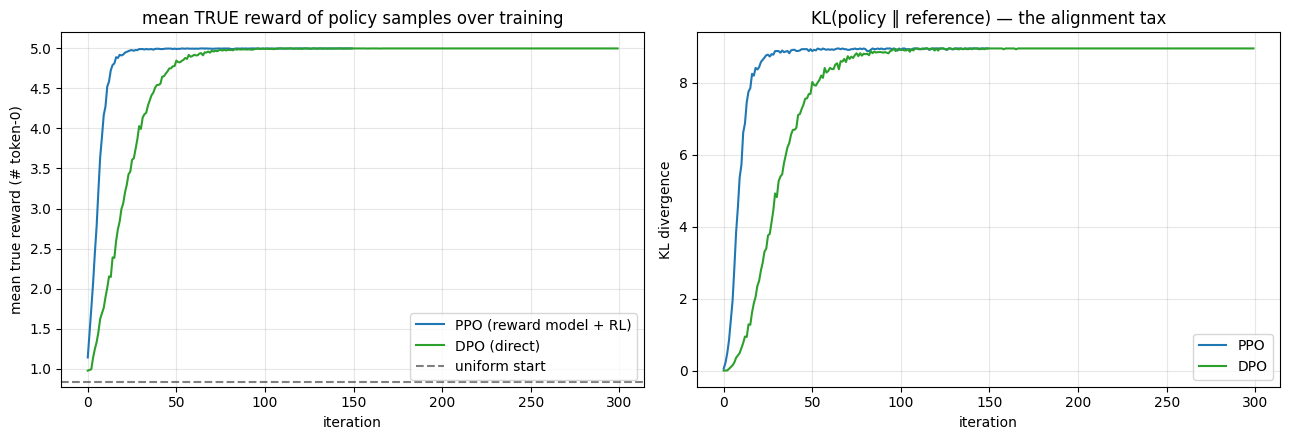

Both methods move the policy toward the preferred behavior (more token-0), trading a bounded KL from the reference.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ppo_reward, color="tab:blue", label="PPO (reward model + RL)")
ax[0].plot(dpo_reward, color="tab:green", label="DPO (direct)")
ax[0].axhline(T/V, ls="--", color="k", alpha=0.5, label="uniform start")
ax[0].set_title("mean TRUE reward of policy samples over training")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("mean true reward (# token-0)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ppo_kl, color="tab:blue", label="PPO"); ax[1].plot(dpo_kl, color="tab:green", label="DPO")
ax[1].set_title("KL(policy ‖ reference) — the alignment tax")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("KL divergence"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Both methods move the policy toward the preferred behavior (more token-0), trading a bounded KL from the reference.")
for nm, rew in (("PPO", ppo_reward), ("DPO", dpo_reward)):
    assert rew[-1] > 2 * (T / V), \
        f"{nm} did not move the policy: reward {rew[-1]:.2f} vs the uniform baseline {T/V:.2f}"


**What to notice.** Both PPO and DPO **increase the true reward** — the policy learns to produce more of the preferred token — starting from the uniform reference, and here both drive it all the way to the optimum (reward 5 = all token-0). The right plot shows the **KL cost** they pay to get there: as the policy specializes, it moves further from the reference. The $\beta$ term sets *how far* it's allowed to move — the **reward-vs-KL tradeoff** (sweep it in Exercise 1: bigger β ⇒ stays closer to the reference, lower reward).

Why does this KL leash matter, if reaching the optimum is *good* here? Because in **real** RLHF the reward model is **imperfect** — over-optimizing it produces "reward-hacked" gibberish that scores high but reads badly. The KL-to-reference is the safety rail that keeps the policy near the coherent pretrained model so it can't run off exploiting the reward model's flaws (set β→0 in Exercise 2 to see the collapse). The key contrast between the methods: **PPO** needed a trained reward model, sampling, advantages, and clipped RL updates (§2); **DPO** got the same alignment from a *one-line supervised loss* on the preference pairs (§3) — no reward model, no sampling loop. That simplicity and stability is why DPO (and its descendants IPO, KTO, ORPO) largely displaced PPO for preference tuning, though PPO-style RL is still used for the largest, most capable models.

## 4. The full RLHF pipeline (context)
Real alignment stacks three stages:
1. **SFT** — supervised fine-tune on human *demonstrations* of good responses (teaches the format/behavior).
2. **Reward modeling** — Bradley-Terry on human *comparisons* (§1).
3. **RL (PPO) or DPO** — optimize the SFT policy toward the preference signal with a KL leash (§2/§3).
This is how InstructGPT → ChatGPT was made. The KL-to-reference term is the crucial safety rail throughout — it's what keeps an aligned model from "reward hacking" into gibberish that happens to score high.

## 5. What you built / learned
- **Reward model** via **Bradley-Terry** loss on preference comparisons — recovered the true preference from pairwise labels.
- **PPO**: clipped policy-gradient maximizing reward − β·KL; the original RLHF optimizer.
- **DPO**: the algebraic collapse of RLHF into a simple preference-classification loss — no reward model, no RL.
- The **KL-to-reference** leash that prevents reward hacking, and the SFT → RM → RL/DPO pipeline.

## 6. Exercises
1. **β sweep.** Vary the KL weight β for both methods; plot reward vs KL (the alignment frontier). What does large/small β do?
2. **Reward hacking.** Set β=0 and watch the policy collapse onto a degenerate max-reward output; relate to real reward hacking.
3. **Noisy preferences.** Flip 20% of preference labels; how robust are the reward model / DPO?
4. **Derive DPO.** Work through the algebra: from the KL-regularized objective's optimal policy $\pi^*\propto\pi_\text{ref}e^{r/\beta}$, recover the DPO loss.
5. **PPO details.** Add a value-function baseline and GAE; does it stabilize PPO vs the simple advantage here?
6. **KTO / IPO.** Implement one DPO variant and compare on the toy.

## 7. Interview / residency framing
- *"What is RLHF?"* → align an LM to human preferences: SFT, then a Bradley-Terry reward model on comparisons, then RL (PPO) or DPO to maximize reward − β·KL(π‖ref).
- *"Why a reward model instead of direct labels?"* → humans compare more reliably than they score; BT turns comparisons into a differentiable reward.
- *"Why the KL penalty?"* → keeps the policy near the coherent pretrained model; prevents reward hacking / mode collapse.
- *"PPO vs DPO?"* → PPO = reward model + sampling + clipped RL (complex, powerful); DPO = closed-form collapse into a direct preference-classification loss (simple, stable), now dominant for preference tuning.
- *"What is reward hacking?"* → the policy exploits flaws in the reward model to score high while behaving badly; the KL leash and better reward models mitigate it.

## 📚 References & papers

This notebook reproduces / builds on:

- **Training language models to follow instructions with human feedback (InstructGPT)** — Ouyang et al. (2022), arXiv:2203.02155. The RLHF pipeline behind ChatGPT.
- **Deep Reinforcement Learning from Human Preferences** — Christiano et al. (2017), arXiv:1706.03741. Reward-model-from-comparisons.
- **Proximal Policy Optimization Algorithms (PPO)** — Schulman et al. (2017), arXiv:1707.06347.
- **Direct Preference Optimization (DPO)** — Rafailov et al. (2023), arXiv:2305.18290. The reward-model-free method.
- **Rank Analysis of Incomplete Block Designs (Bradley-Terry model)** — Bradley & Terry (1952).

---
**Next:** *Tier 4 · Notebook 22 — Instruction tuning & evaluation*: turning a base model into an instruction-follower, and building an eval harness — because measuring an LLM well is the genuinely hard part.
